# Exploratory Data Analysis (EDA)



In [2]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from collections import Counter
import csv
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

STOPWORDS = {
    'the', 'a', 'an', 'and', 'or', 'to', 'of', 'in', 'on', 'for', 'is', 'are',
    'at', 'it', 'this', 'that', 'with', 'as', 'be', 'by', 'from', 'i', 'you',
    'your', 'my', 'we', 'our', 'they', 'he', 'she', 'them', 'me', 'us',
    'na', 'ng', 'sa', 'ang', 'mga', 'si', 'ako', 'ko', 'mo', 'ka', 'ni', 'nang',
    'yung', 'yan', 'ito', 'iyon', 'din', 'rin', 'lang', 'talaga', 'kasi', 'pero'
}


def extract_tokens(series):
    tokens = []
    for value in series.fillna('').astype(str):
        words = re.findall(r"[a-zA-Z']{3,}", value.lower())
        tokens.extend([word for word in words if word not in STOPWORDS])
    return tokens


def top_tokens(series, n=15):
    return pd.DataFrame(Counter(extract_tokens(series)).most_common(n), columns=['token', 'count'])


def tokenize_text(value):
    words = re.findall(r"[a-zA-Z']{3,}", str(value).lower())
    return [word for word in words if word not in STOPWORDS]


def keyword_token_sequences(keywords):
    keyword_sequences = []
    seen_sequences = set()
    for keyword in keywords:
        token_tuple = tuple(tokenize_text(keyword))
        if token_tuple and token_tuple not in seen_sequences:
            seen_sequences.add(token_tuple)
            keyword_sequences.append(token_tuple)
    return keyword_sequences


def ngram_contains_keyword(ngram_tokens, keyword_sequences):
    for keyword_tokens in keyword_sequences:
        keyword_len = len(keyword_tokens)
        if keyword_len > len(ngram_tokens):
            continue
        for idx in range(len(ngram_tokens) - keyword_len + 1):
            if tuple(ngram_tokens[idx:idx + keyword_len]) == keyword_tokens:
                return True
    return False


def extract_ngrams(series, ngram_size=2, keyword_sequences=None):
    ngrams = []
    for value in series.fillna('').astype(str):
        tokens = tokenize_text(value)
        if len(tokens) < ngram_size:
            continue
        for idx in range(len(tokens) - ngram_size + 1):
            ngram_tokens = tokens[idx:idx + ngram_size]
            if keyword_sequences and not ngram_contains_keyword(ngram_tokens, keyword_sequences):
                continue
            ngrams.append(' '.join(ngram_tokens))
    return ngrams


def top_ngrams(series, ngram_size=2, top_k=10, keyword_sequences=None):
    ngram_counts = Counter(extract_ngrams(series, ngram_size=ngram_size, keyword_sequences=keyword_sequences)).most_common(top_k)
    return pd.DataFrame(ngram_counts, columns=['ngram', 'count'])


def build_language_ngram_counts(frame, keyword_file_map, text_col='cleaned_text', ngram_sizes=(2, 3, 4), top_k=10):
    if 'language' not in frame.columns:
        raise KeyError('The dataset must contain a language column for n-gram analysis.')

    text_source_col = text_col if text_col in frame.columns else 'text'
    if text_source_col not in frame.columns:
        raise KeyError('The dataset must contain cleaned_text or text for n-gram analysis.')

    working_df = frame[['language', text_source_col]].copy()
    working_df['language'] = working_df['language'].fillna('unknown').astype(str).str.strip().str.lower()
    working_df[text_source_col] = working_df[text_source_col].fillna('').astype(str)

    language_summary_rows = []
    ngram_tables = []

    for language_code, language_posts in working_df.groupby('language'):
        keywords = load_language_keywords(keyword_file_map[language_code]) if language_code in keyword_file_map else []
        keyword_sequences = keyword_token_sequences(keywords)
        total_posts = len(language_posts)
        total_tokens = int(sum(len(tokenize_text(value)) for value in language_posts[text_source_col]))
        language_summary_rows.append({
            'language': language_code,
            'keyword_count_available': len(keywords),
            'total_posts': total_posts,
            'total_tokens': total_tokens,
            'avg_tokens_per_post': round(total_tokens / total_posts, 2) if total_posts else 0.0,
        })

        for ngram_size in ngram_sizes:
            top_ngram_df = top_ngrams(
                language_posts[text_source_col],
                ngram_size=ngram_size,
                top_k=top_k,
                keyword_sequences=keyword_sequences,
            )
            if top_ngram_df.empty:
                continue
            top_ngram_df.insert(0, 'ngram_size', ngram_size)
            top_ngram_df.insert(0, 'language', language_code)
            ngram_tables.append(top_ngram_df)

    summary_df = pd.DataFrame(language_summary_rows).sort_values('total_posts', ascending=False).reset_index(drop=True)
    ngram_counts_df = pd.concat(ngram_tables, ignore_index=True) if ngram_tables else pd.DataFrame(
        columns=['language', 'ngram_size', 'ngram', 'count']
    )

    return summary_df, ngram_counts_df


def plot_language_ngram_summary(ngram_counts_df, top_k=10):
    if ngram_counts_df.empty:
        print('No language n-gram counts are available to plot.')
        return

    for ngram_size in sorted(ngram_counts_df['ngram_size'].dropna().unique()):
        ngram_subset = ngram_counts_df[ngram_counts_df['ngram_size'] == ngram_size].copy()
        languages = ngram_subset['language'].drop_duplicates().tolist()
        fig, axes = plt.subplots(len(languages), 1, figsize=(11, max(4, len(languages) * 3.5)), squeeze=False)

        for ax, language_code in zip(axes.flat, languages):
            top_language_ngrams = ngram_subset[ngram_subset['language'] == language_code].head(top_k)
            sns.barplot(data=top_language_ngrams, x='count', y='ngram', ax=ax, palette='rocket')
            ax.set_title(f'Top {min(top_k, len(top_language_ngrams))} {ngram_size}-Grams for {language_code}')
            ax.set_xlabel('Count')
            ax.set_ylabel(f'{ngram_size}-Gram')

        plt.tight_layout()
        plt.show()
LANGUAGE_KEYWORD_FILES = {
    'en': Path('../docs/keywords/by_language/english/english_keywords.csv'),
    'tl': Path('../docs/keywords/by_language/filipino_keywords.csv'),
    'ceb': Path('../docs/keywords/by_language/cebuano_keywords.csv'),
    'ilo': Path('../docs/keywords/by_language/ilocano_keywords.csv'),
    'hil': Path('../docs/keywords/by_language/hiligaynon_keywords.csv'),
}


def load_language_keywords(keyword_path):
    keyword_values = []

    with open(keyword_path, newline='', encoding='utf-8-sig') as keyword_file:
        for row in csv.reader(keyword_file):
            keyword_values.extend(row)

    cleaned_keywords = []
    seen_keywords = set()
    for keyword in keyword_values:
        keyword = re.sub(r'\s+', ' ', str(keyword).strip().lower())
        if not keyword or keyword == 'nan' or keyword.startswith('unnamed:'):
            continue
        if keyword not in seen_keywords:
            seen_keywords.add(keyword)
            cleaned_keywords.append(keyword)

    return cleaned_keywords


def calculate_keyword_matches(group_df, keywords, text_col, group_values, total_posts):
    text_series = group_df[text_col].str.replace(r'\s+', ' ', regex=True)
    keyword_counts = []
    matched_any_keyword = pd.Series(False, index=group_df.index)

    for keyword in keywords:
        pattern = rf'(?<!\w){re.escape(keyword)}(?!\w)'
        matched_posts = text_series.str.contains(pattern, regex=True, na=False)
        matched_count = int(matched_posts.sum())
        if matched_count > 0:
            matched_any_keyword = matched_any_keyword | matched_posts
        keyword_counts.append({
            **group_values,
            'keyword': keyword,
            'matched_post_count': matched_count,
            'match_rate_pct': round((matched_count / total_posts) * 100, 2) if total_posts else 0.0,
        })

    keyword_count_df = pd.DataFrame(keyword_counts)
    if keyword_count_df.empty:
        keyword_count_df = pd.DataFrame(columns=[*group_values.keys(), 'keyword', 'matched_post_count', 'match_rate_pct'])
    else:
        keyword_count_df = keyword_count_df.sort_values(['matched_post_count', 'keyword'], ascending=[False, True]).reset_index(drop=True)

    summary_row = {
        **group_values,
        'total_posts': total_posts,
        'posts_with_keyword': int(matched_any_keyword.sum()),
        'match_rate_pct': round((matched_any_keyword.sum() / total_posts) * 100, 2) if total_posts else 0.0,
        'distinct_keywords_hit': int((keyword_count_df['matched_post_count'] > 0).sum()) if not keyword_count_df.empty else 0,
    }

    return summary_row, keyword_count_df


def build_language_keyword_counts(frame, keyword_file_map, text_col='cleaned_text', source_col='source'):
    if 'language' not in frame.columns:
        raise KeyError('The dataset must contain a language column for keyword analysis.')

    text_source_col = text_col if text_col in frame.columns else 'text'
    if text_source_col not in frame.columns:
        raise KeyError('The dataset must contain cleaned_text or text for keyword analysis.')

    columns = ['language', text_source_col]
    has_source = source_col in frame.columns
    if has_source:
        columns.insert(1, source_col)

    working_df = frame[columns].copy()
    working_df['language'] = working_df['language'].fillna('unknown').astype(str).str.strip().str.lower()
    working_df[text_source_col] = working_df[text_source_col].fillna('').astype(str).str.lower()
    if has_source:
        working_df[source_col] = working_df[source_col].fillna('unknown').astype(str).str.strip().str.lower()

    language_summary_rows = []
    language_keyword_tables = []
    source_language_summary_rows = []
    source_language_keyword_tables = []

    for language_code, keyword_path in keyword_file_map.items():
        keywords = load_language_keywords(keyword_path)
        language_posts = working_df[working_df['language'] == language_code].copy()
        total_posts = len(language_posts)

        if total_posts == 0:
            language_summary_rows.append({
                'language': language_code,
                'keyword_file': keyword_path.name,
                'keyword_count_available': len(keywords),
                'total_posts': 0,
                'posts_with_keyword': 0,
                'match_rate_pct': 0.0,
                'distinct_keywords_hit': 0,
            })
            continue

        summary_row, keyword_count_df = calculate_keyword_matches(
            language_posts,
            keywords,
            text_source_col,
            {'language': language_code},
            total_posts,
        )
        summary_row['keyword_file'] = keyword_path.name
        summary_row['keyword_count_available'] = len(keywords)
        language_summary_rows.append(summary_row)
        language_keyword_tables.append(keyword_count_df)

        if has_source:
            for source_name, source_posts in language_posts.groupby(source_col):
                source_total_posts = len(source_posts)
                source_summary_row, source_keyword_count_df = calculate_keyword_matches(
                    source_posts,
                    keywords,
                    text_source_col,
                    {'source': source_name, 'language': language_code},
                    source_total_posts,
                )
                source_language_summary_rows.append(source_summary_row)
                source_language_keyword_tables.append(source_keyword_count_df)

    summary_df = pd.DataFrame(language_summary_rows).sort_values('total_posts', ascending=False).reset_index(drop=True)
    keyword_counts_df = pd.concat(language_keyword_tables, ignore_index=True) if language_keyword_tables else pd.DataFrame(
        columns=['language', 'keyword', 'matched_post_count', 'match_rate_pct']
    )

    source_language_summary_df = pd.DataFrame(source_language_summary_rows)
    if not source_language_summary_df.empty:
        source_language_summary_df = source_language_summary_df.sort_values(['source', 'total_posts', 'language'], ascending=[True, False, True]).reset_index(drop=True)

    source_language_keyword_counts_df = pd.concat(source_language_keyword_tables, ignore_index=True) if source_language_keyword_tables else pd.DataFrame(
        columns=['source', 'language', 'keyword', 'matched_post_count', 'match_rate_pct']
    )

    return summary_df, keyword_counts_df, source_language_summary_df, source_language_keyword_counts_df


def plot_language_keyword_summary(summary_df, keyword_counts_df, source_language_keyword_counts_df=None, top_n=10):
    if summary_df.empty:
        print('No language keyword summary available to plot.')
        return

    plot_summary = summary_df.copy()
    plt.figure(figsize=(9, 4))
    sns.barplot(data=plot_summary, x='language', y='match_rate_pct', palette='crest')
    plt.title('Share of Posts With at Least One Curated Keyword by Language')
    plt.xlabel('Language')
    plt.ylabel('Matched Posts (%)')
    plt.ylim(0, max(5, plot_summary['match_rate_pct'].max() * 1.15 if not plot_summary['match_rate_pct'].empty else 5))
    plt.tight_layout()
    plt.show()

    nonzero_counts = keyword_counts_df[keyword_counts_df['matched_post_count'] > 0].copy()
    if nonzero_counts.empty:
        print('No keyword matches were found for the configured languages.')
        return

    languages = nonzero_counts['language'].drop_duplicates().tolist()
    fig, axes = plt.subplots(len(languages), 1, figsize=(10, max(4, len(languages) * 3.5)), squeeze=False)

    for ax, language_code in zip(axes.flat, languages):
        top_keywords = nonzero_counts[nonzero_counts['language'] == language_code].head(top_n)
        sns.barplot(data=top_keywords, x='matched_post_count', y='keyword', ax=ax, palette='viridis')
        ax.set_title(f'Top {min(top_n, len(top_keywords))} Matched Keywords for {language_code}')
        ax.set_xlabel('Matched Posts')
        ax.set_ylabel('Keyword')

    plt.tight_layout()
    plt.show()

    if source_language_keyword_counts_df is None or source_language_keyword_counts_df.empty:
        return

    nonzero_source_counts = source_language_keyword_counts_df[source_language_keyword_counts_df['matched_post_count'] > 0].copy()
    if nonzero_source_counts.empty:
        print('No website-level keyword matches were found for the configured languages.')
        return

    for source_name in nonzero_source_counts['source'].drop_duplicates().tolist():
        source_subset = nonzero_source_counts[nonzero_source_counts['source'] == source_name]
        languages = source_subset['language'].drop_duplicates().tolist()
        fig, axes = plt.subplots(len(languages), 1, figsize=(10, max(4, len(languages) * 3.5)), squeeze=False)

        for ax, language_code in zip(axes.flat, languages):
            top_keywords = source_subset[source_subset['language'] == language_code].head(top_n)
            sns.barplot(data=top_keywords, x='matched_post_count', y='keyword', ax=ax, palette='mako')
            ax.set_title(f'Top {min(top_n, len(top_keywords))} Matched Keywords for {source_name} ({language_code})')
            ax.set_xlabel('Matched Posts')
            ax.set_ylabel('Keyword')

        plt.tight_layout()
        plt.show()


In [3]:
candidate_paths = [
    Path('../data/processed/merged_data.csv'),
    Path('../data/processed/merged_data_2.csv')
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f'None of the expected datasets exist: {candidate_paths}')

df = pd.read_csv(DATA_PATH)

for col in ['created_at', 'date_posted', 'date', 'updated_at', 'date_collected']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce', utc=True)

for col in ['view_count', 'like_count', 'share_count', 'comment_count']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'source' in df.columns:
    df['source'] = df['source'].fillna('unknown').astype(str).str.strip().str.lower()

if 'language' in df.columns:
    df['language'] = df['language'].fillna('unknown').astype(str).str.strip().str.lower()

if 'text' in df.columns:
    df['text'] = df['text'].fillna('').astype(str)

if 'cleaned_text' in df.columns:
    df['cleaned_text'] = df['cleaned_text'].fillna('').astype(str)
elif 'text' in df.columns:
    df['cleaned_text'] = df['text']

date_candidates = ['created_at', 'date_posted', 'date']
analysis_date_col = next((col for col in date_candidates if col in df.columns and df[col].notna().any()), None)
df['analysis_date'] = df[analysis_date_col] if analysis_date_col else pd.NaT

analysis_text_col = 'cleaned_text' if 'cleaned_text' in df.columns else 'text' if 'text' in df.columns else None

if analysis_text_col:
    df['char_len'] = df[analysis_text_col].str.len()
    df['word_len'] = df[analysis_text_col].str.split().str.len()
    df['is_empty_text'] = df[analysis_text_col].str.strip().eq('')

metric_cols = [col for col in ['view_count', 'like_count', 'share_count', 'comment_count'] if col in df.columns]
if metric_cols:
    df['engagement_total'] = df[metric_cols].fillna(0).sum(axis=1)

preview_cols = [col for col in ['source', 'language', 'analysis_date', 'cleaned_text'] if col in df.columns]
if metric_cols:
    preview_cols += metric_cols[:2]

print(f'Loaded: {DATA_PATH}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Primary analysis date column: {analysis_date_col or "None"}')
print(f'Available metric columns: {metric_cols if metric_cols else "None"}')

display(df[preview_cols].head() if preview_cols else df.head())


Loaded: ../data/processed/merged_data.csv
Shape: 30,357 rows x 19 columns
Primary analysis date column: created_at
Available metric columns: ['view_count', 'like_count', 'share_count', 'comment_count']


,source,language,analysis_date,cleaned_text,view_count,like_count
0,twitter,tl,2025-09-21 23:53:27+00:00,anong gusto mo gawin niya makipagbarda sa mga ...,NaN,NaN
1,twitter,en,2025-09-21 23:19:27+00:00,thoughts on the officiating crew tonight? that...,NaN,NaN
2,twitter,en,2025-09-21 23:18:03+00:00,horrible game when it comes to the vibe and a ...,NaN,NaN
3,twitter,en,2025-09-21 23:14:05+00:00,shit game. theres no other way to put it. refs...,NaN,NaN
4,twitter,en,2025-09-21 23:11:38+00:00,nixs accuracy on deep throws was ass.,NaN,NaN


## 1) Structure and Coverage


In [4]:
schema_profile = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null_count': df.notna().sum(),
    'null_count': df.isna().sum(),
    'null_pct': (df.isna().mean() * 100).round(2),
    'unique_count': df.nunique(dropna=True)
}).sort_values(['null_pct', 'unique_count'], ascending=[False, False])

display(schema_profile)

dataset_summary = {
    'rows': len(df),
    'columns': df.shape[1],
    'source_count': int(df['source'].nunique()) if 'source' in df.columns else 0,
    'language_count': int(df['language'].nunique()) if 'language' in df.columns else 0,
    'date_column_used': analysis_date_col or 'None',
    'valid_dates': int(df['analysis_date'].notna().sum()) if 'analysis_date' in df.columns else 0,
    'date_min': df['analysis_date'].min() if 'analysis_date' in df.columns and df['analysis_date'].notna().any() else pd.NaT,
    'date_max': df['analysis_date'].max() if 'analysis_date' in df.columns and df['analysis_date'].notna().any() else pd.NaT,
}

display(pd.Series(dataset_summary, name='value').to_frame())

if 'source' in df.columns:
    source_mix = df['source'].value_counts(dropna=False).rename_axis('source').to_frame('count')
    source_mix['pct'] = (source_mix['count'] / len(df) * 100).round(2)
    display(source_mix)


,dtype,non_null_count,null_count,null_pct,unique_count
comment_count,float64,985,29372,96.76,215
view_count,float64,1802,28555,94.06,655
share_count,float64,2089,28268,93.12,341
like_count,float64,26123,4234,13.95,1501
id,str,30357,0,0.00,30357
external_post_id,str,30357,0,0.00,30357
date_posted,"datetime64[us, UTC]",30357,0,0.00,29651
created_at,"datetime64[us, UTC]",30357,0,0.00,29651
analysis_date,"datetime64[us, UTC]",30357,0,0.00,29651
text,str,30357,0,0.00,29203


,value
rows,30357
columns,19
source_count,5
language_count,4
date_column_used,created_at
valid_dates,30357
date_min,2009-02-10 12:00:12+00:00
date_max,2026-05-15 14:07:29+00:00


,count,pct
source,,
reddit,23124,76.17
threads,3645,12.01
twitter,2973,9.79
tiktok,543,1.79
facebook,72,0.24


## 2) Data Quality and Missingness


In [5]:
rows_with_hilanat = df[df["text"].str.contains("hilanat", case=False, na=False)]
print(rows_with_hilanat)






                                         id   source     external_post_id  \
818    ee29ef9a-2608-478b-ad4f-632cd29458cd  twitter  2025627713244172502   
956    03bce1b0-f10e-42e0-8b19-1e25af229bee  twitter  2025267841109463067   
980    f683ee54-a8eb-4efe-bf8b-fba523ab6316  twitter  2025223059830088137   
1041   57806326-bae5-4f3f-8df1-21a6613cd5e4  twitter  2025132867450437867   
1080   2b41859b-c463-4a7f-927b-3be83be629f2  twitter  2025033141833138509   
...                                     ...      ...                  ...   
9846   5cfb914e-3cbe-4825-8e09-3ba5b6bb6bef   reddit              15v0zib   
9847   bc4916bd-933e-4738-9a20-eb07381dce63   reddit               o4lh31   
11682  60fc0257-f57c-417e-b7db-d5012a71345d   reddit              1rp0u7q   
12145  2c53235c-9f03-468f-baa6-27e65f4a5f16   reddit              1svcddu   
14116  3030dea4-501d-486a-9f12-7705cf1aaf41   reddit              1rjlhpl   

                                                    text  \
818    taas hil

,count
exact_duplicate_rows,0
duplicate_id_rows,0
duplicate_text_rows,1354
duplicate_source_external_post_id,0
empty_text_rows,93
short_text_rows_lt_5_words,993


,missing_count,missing_pct
comment_count,29372,96.76
view_count,28555,94.06
share_count,28268,93.12
like_count,4234,13.95
is_empty_text,0,0.00
word_len,0,0.00
char_len,0,0.00
analysis_date,0,0.00
updated_at,0,0.00
created_at,0,0.00


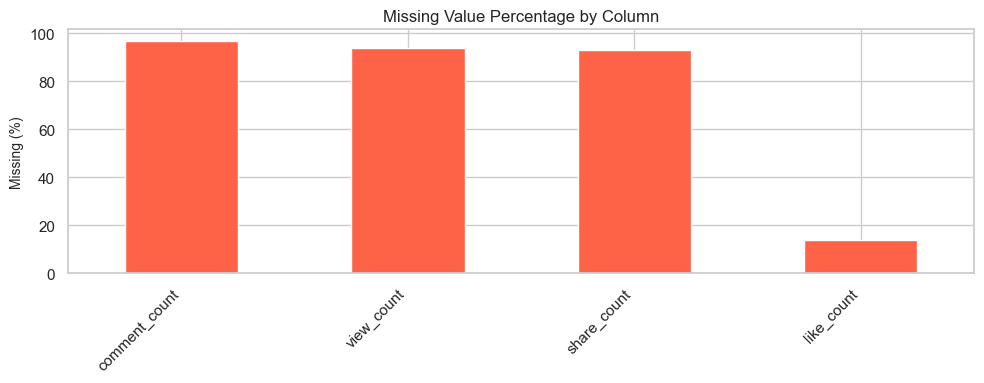

,text,cleaned_text,language,analysis_date,view_count,like_count,share_count,comment_count
source,,,,,,,,
facebook,100.0,100.0,100.0,100.0,0.0,100.0,0.0,0.0
reddit,100.0,100.0,100.0,100.0,0.0,100.0,0.0,0.0
threads,100.0,100.0,100.0,100.0,22.6,35.5,12.8,0.0
tiktok,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0
twitter,100.0,100.0,100.0,100.0,14.6,55.0,36.3,14.9


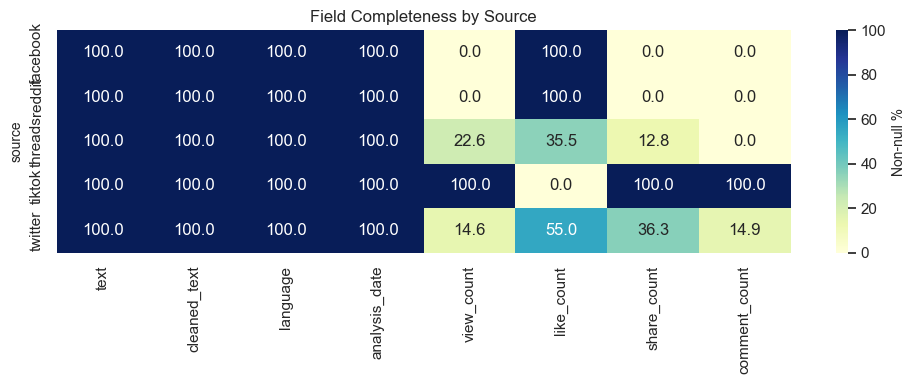

In [ ]:
quality_checks = {
    'exact_duplicate_rows': int(df.duplicated().sum()),
    'duplicate_id_rows': int(df.duplicated(subset=['id']).sum()) if 'id' in df.columns else np.nan,
    'duplicate_text_rows': int(df.duplicated(subset=[analysis_text_col]).sum()) if analysis_text_col else np.nan,
    'duplicate_source_external_post_id': int(df.duplicated(subset=['source', 'external_post_id']).sum()) if {'source', 'external_post_id'}.issubset(df.columns) else np.nan,
    'empty_text_rows': int(df['is_empty_text'].sum()) if 'is_empty_text' in df.columns else np.nan,
    'short_text_rows_lt_5_words': int((df['word_len'] < 5).sum()) if 'word_len' in df.columns else np.nan,
}

display(pd.Series(quality_checks, name='count').to_frame())

missing_df = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
}).sort_values('missing_pct', ascending=False)

display(missing_df)

if (missing_df['missing_count'] > 0).any():
    plt.figure(figsize=(10, 4))
    missing_df[missing_df['missing_count'] > 0]['missing_pct'].plot(kind='bar', color='tomato')
    plt.title('Missing Value Percentage by Column')
    plt.ylabel('Missing (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

completeness_cols = [col for col in ['text', 'cleaned_text', 'language', 'analysis_date'] + metric_cols if col in df.columns]
if 'source' in df.columns and completeness_cols:
    completeness_by_source = (df.groupby('source')[completeness_cols].apply(lambda x: x.notna().mean() * 100)).round(1)
    display(completeness_by_source)

    plt.figure(figsize=(10, 4))
    sns.heatmap(completeness_by_source, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Non-null %'})
    plt.title('Field Completeness by Source')
    plt.tight_layout()
    plt.show()


## 3) Source, Language, and Platform Mix


,count
source,
reddit,23124
threads,3645
twitter,2973
tiktok,543
facebook,72


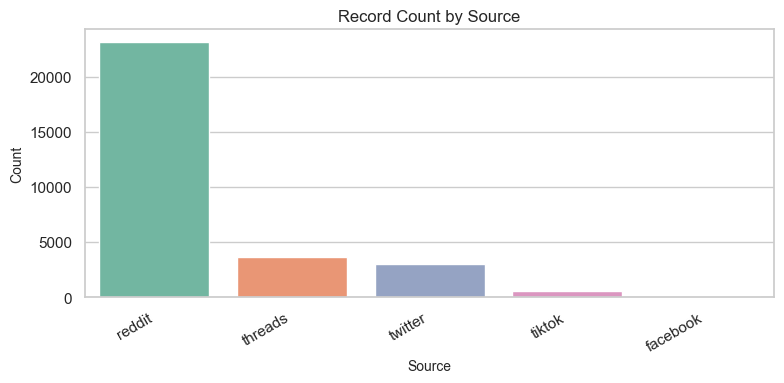

,count
language,
en,15853
tl,13659
ceb,821
ilo,24


language,en,tl,ceb,ilo
source,,,,
facebook,9,63,0,0
reddit,11471,11115,523,15
threads,2384,1055,201,5
tiktok,341,173,27,2
twitter,1648,1253,70,2


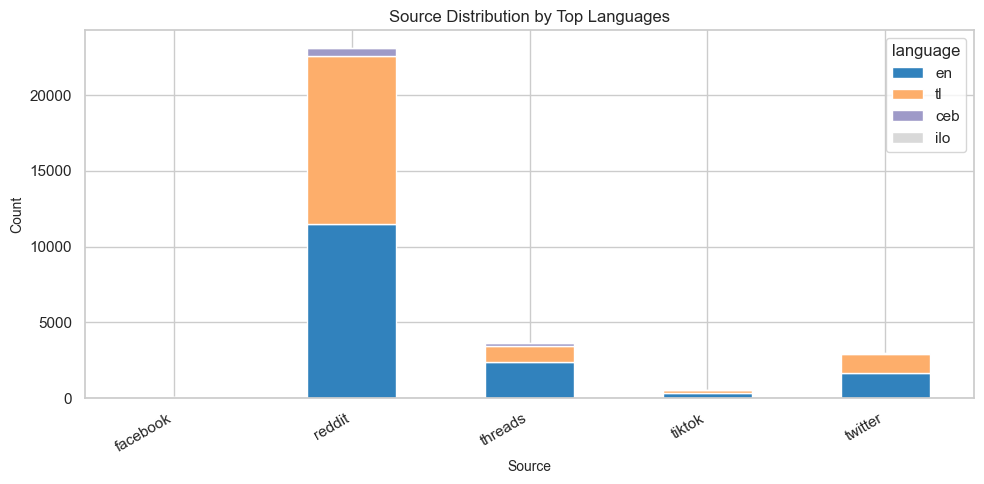

,view_count,like_count,share_count,comment_count
source,,,,
facebook,0.0,100.0,0.0,0.0
reddit,0.0,100.0,0.0,0.0
threads,22.6,35.5,12.8,0.0
tiktok,100.0,0.0,100.0,100.0
twitter,14.6,55.0,36.3,14.9


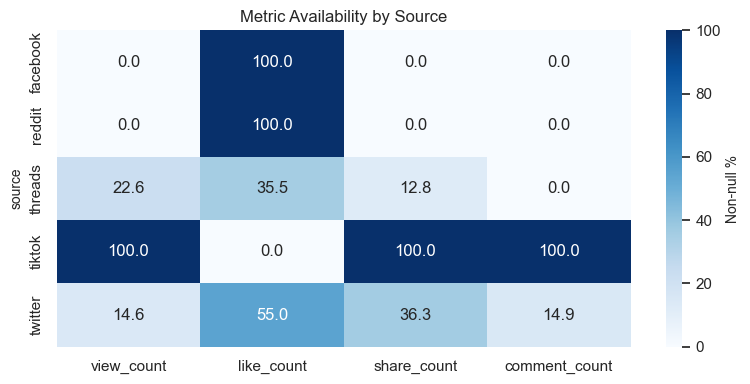

In [ ]:
if 'source' not in df.columns:
    print('No source column found.')
else:
    source_counts = df['source'].value_counts().sort_values(ascending=False)
    display(source_counts.to_frame('count'))

    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x='source', order=source_counts.index, palette='Set2')
    plt.title('Record Count by Source')
    plt.xlabel('Source')
    plt.ylabel('Count')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    if 'language' in df.columns:
        language_counts = df['language'].value_counts().head(10)
        display(language_counts.to_frame('count'))

        source_language = pd.crosstab(df['source'], df['language'])
        top_languages = language_counts.index.tolist()
        source_language = source_language.loc[:, [lang for lang in top_languages if lang in source_language.columns]]
        display(source_language)

        if not source_language.empty:
            source_language.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='tab20c')
            plt.title('Source Distribution by Top Languages')
            plt.xlabel('Source')
            plt.ylabel('Count')
            plt.xticks(rotation=30, ha='right')
            plt.tight_layout()
            plt.show()

    if metric_cols:
        metric_presence = (df.groupby('source')[metric_cols].apply(lambda x: x.notna().mean() * 100)).round(1)
        display(metric_presence)

        plt.figure(figsize=(8, 4))
        sns.heatmap(metric_presence, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Non-null %'})
        plt.title('Metric Availability by Source')
        plt.tight_layout()
        plt.show()


## 4) Temporal Patterns


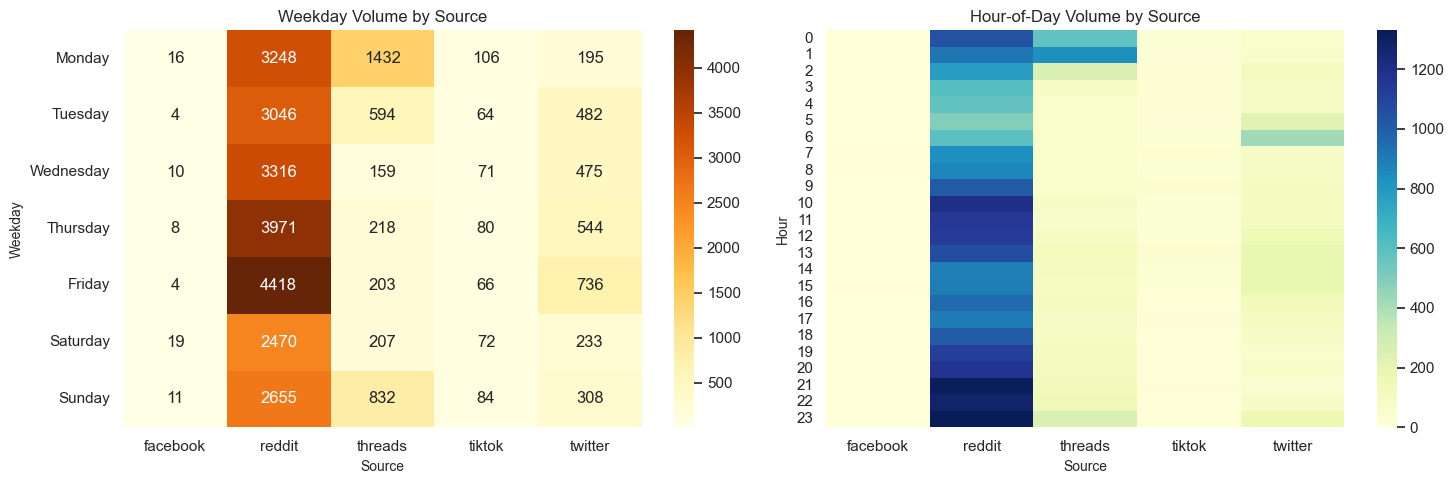

source,facebook,reddit,threads,tiktok,twitter
date_only,,,,,
2026-05-06,0,337,0,0,0
2026-05-07,0,349,0,0,0
2026-05-08,0,388,0,0,0
2026-05-09,0,349,0,0,1
2026-05-10,0,404,0,0,1
2026-05-11,0,499,0,0,1
2026-05-12,0,658,0,0,2
2026-05-13,0,809,0,0,0
2026-05-14,0,1462,0,0,14


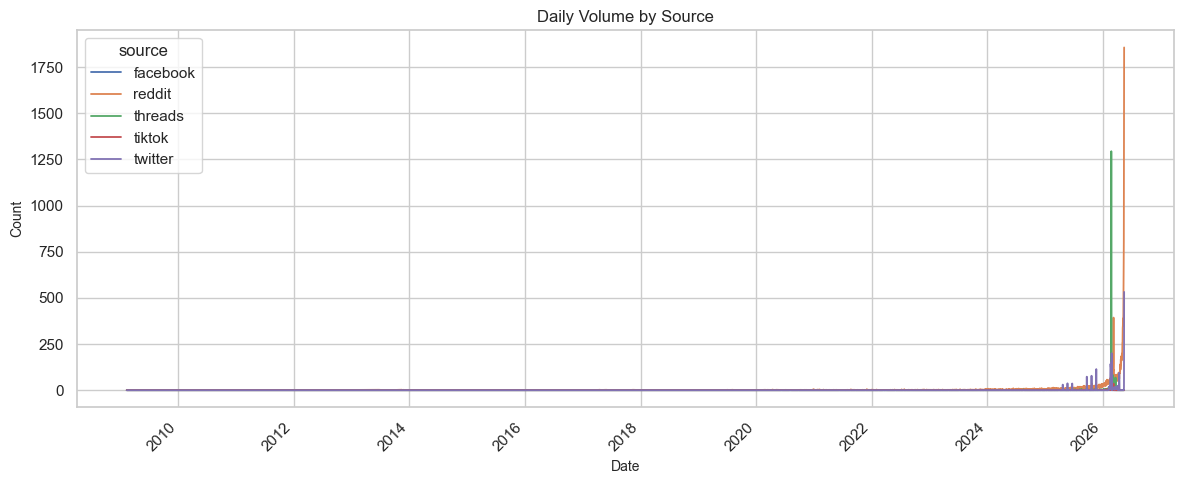

In [ ]:
if analysis_date_col is None or df['analysis_date'].isna().all():
    print('No usable datetime column found for temporal analysis.')
else:
    ts = df.dropna(subset=['analysis_date']).copy()
    ts['date_only'] = ts['analysis_date'].dt.date
    ts['weekday'] = pd.Categorical(
        ts['analysis_date'].dt.day_name(),
        categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
        ordered=True,
    )
    ts['hour'] = ts['analysis_date'].dt.hour

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    weekday_source = pd.crosstab(ts['weekday'], ts['source']) if 'source' in ts.columns else pd.crosstab(ts['weekday'], columns='count')
    sns.heatmap(weekday_source, annot=True, fmt='g', cmap='YlOrBr', ax=axes[0])
    axes[0].set_title('Weekday Volume by Source')
    axes[0].set_xlabel('Source')
    axes[0].set_ylabel('Weekday')

    hour_source = pd.crosstab(ts['hour'], ts['source']) if 'source' in ts.columns else pd.crosstab(ts['hour'], columns='count')
    sns.heatmap(hour_source, cmap='YlGnBu', ax=axes[1])
    axes[1].set_title('Hour-of-Day Volume by Source')
    axes[1].set_xlabel('Source')
    axes[1].set_ylabel('Hour')

    plt.tight_layout()
    plt.show()

    if 'source' in ts.columns:
        daily_by_source = ts.pivot_table(index='date_only', columns='source', aggfunc='size', fill_value=0)
        display(daily_by_source.tail(10))

        daily_by_source.plot(figsize=(12, 5), linewidth=1.3)
        plt.title('Daily Volume by Source')
        plt.xlabel('Date')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


## 5) Text Analysis


,count,mean,std,min,50%,75%,90%,95%,99%,max
char_len,30357.0,1184.89,2667.31,0.0,414.0,1159.0,2594.0,4240.4,12630.52,39090.0
word_len,30357.0,205.63,445.03,0.0,74.0,206.0,454.0,744.0,2196.00,7980.0


char_len                       word_len                    
            count median    mean    max    count median   mean   max
source                                                              
facebook       72  138.5   441.0   5984       72   26.5   76.7  1018
reddit      23124  657.0  1509.2  39090    23124  118.0  261.6  7980
threads      3645  144.0   189.6   1377     3645   26.0   33.8   228
tiktok        543   38.0    85.8   3957      543    7.0   14.9   654
twitter      2973   74.0   101.4   2955     2973   14.0   18.7   483

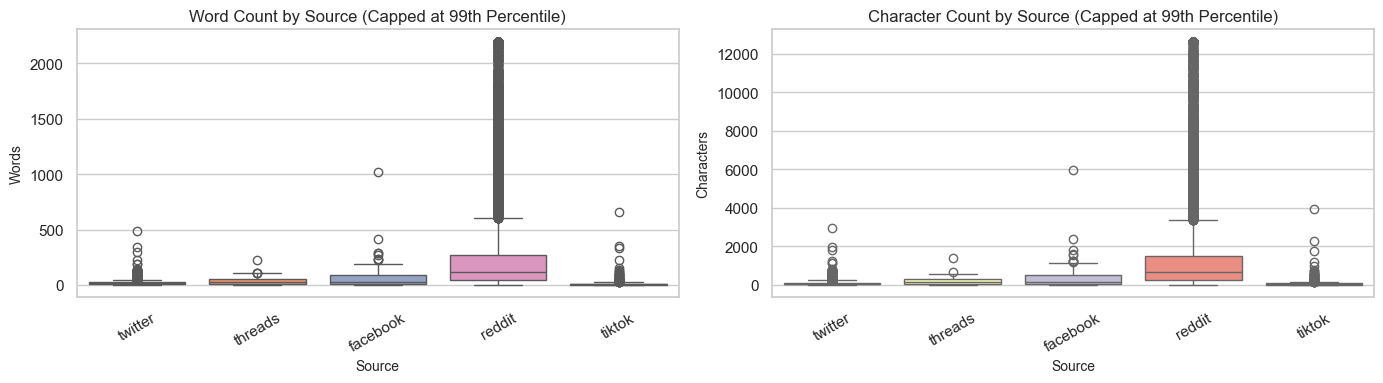

,token,count
0,may,31841
1,hindi,28283
2,naman,21032
3,siya,20679
4,niya,18903
5,nag,18517
6,was,17702
7,kung,17410
8,wala,16643
9,but,16616


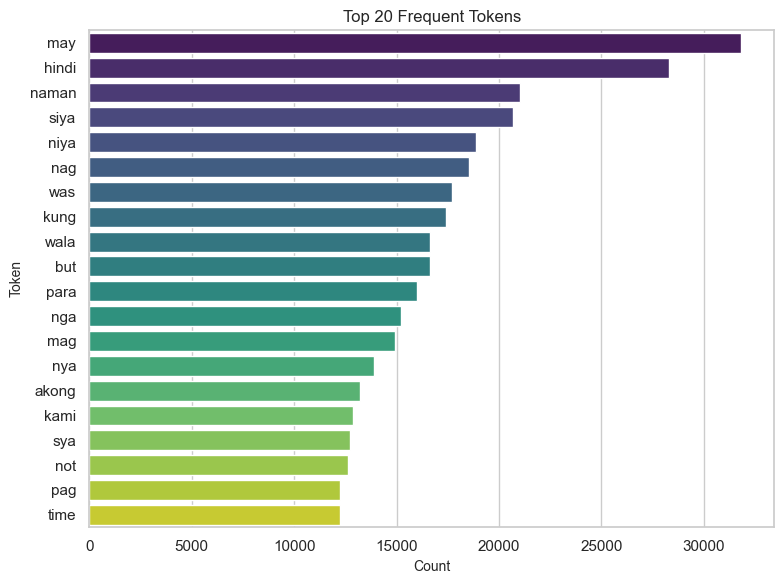

,source,token,count
0,facebook,lagnat,119
1,facebook,may,91
2,facebook,kung,49
3,facebook,pag,47
4,facebook,hindi,43
5,facebook,para,37
6,facebook,bata,35
7,facebook,siya,34
8,facebook,baby,30
9,facebook,gamot,29


In [ ]:
if not analysis_text_col:
    print('No cleaned_text or text column found.')
else:
    text_summary = df[['char_len', 'word_len']].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).transpose().round(2)
    display(text_summary)

    if 'source' in df.columns:
        text_by_source = df.groupby('source')[['char_len', 'word_len']].agg(['count', 'median', 'mean', 'max']).round(1)
        display(text_by_source)

        plot_df = df.copy()
        plot_df['word_len_capped'] = plot_df['word_len'].clip(upper=plot_df['word_len'].quantile(0.99))
        plot_df['char_len_capped'] = plot_df['char_len'].clip(upper=plot_df['char_len'].quantile(0.99))

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        sns.boxplot(data=plot_df, x='source', y='word_len_capped', ax=axes[0], palette='Set2')
        axes[0].set_title('Word Count by Source (Capped at 99th Percentile)')
        axes[0].set_xlabel('Source')
        axes[0].set_ylabel('Words')
        axes[0].tick_params(axis='x', rotation=30)

        sns.boxplot(data=plot_df, x='source', y='char_len_capped', ax=axes[1], palette='Set3')
        axes[1].set_title('Character Count by Source (Capped at 99th Percentile)')
        axes[1].set_xlabel('Source')
        axes[1].set_ylabel('Characters')
        axes[1].tick_params(axis='x', rotation=30)

        plt.tight_layout()
        plt.show()

    token_source = df['cleaned_text'] if 'cleaned_text' in df.columns else df['text']
    top_tokens_overall = top_tokens(token_source, n=20)
    display(top_tokens_overall)

    if not top_tokens_overall.empty:
        plt.figure(figsize=(8, 6))
        sns.barplot(data=top_tokens_overall, x='count', y='token', palette='viridis')
        plt.title('Top 20 Frequent Tokens')
        plt.xlabel('Count')
        plt.ylabel('Token')
        plt.tight_layout()
        plt.show()

    if 'source' in df.columns:
        source_token_tables = []
        for source, group in df.groupby('source'):
            source_tokens = top_tokens(group['cleaned_text'] if 'cleaned_text' in group.columns else group['text'], n=10)
            source_tokens.insert(0, 'source', source)
            source_token_tables.append(source_tokens)

        if source_token_tables:
            display(pd.concat(source_token_tables, ignore_index=True))


## 6) Language N-Gram Analysis

This section focuses on recurring multi-word phrases within each detected language that include at least one curated keyword for that language. Unlike the single-token view above, these n-grams preserve local word order while staying anchored to the disease and symptom vocabulary already defined in the keyword files.

How to read the outputs:
- The language summary table shows how much text each language contributes and how many curated keywords are available for filtering.
- The 2-gram tables and charts surface the most common keyword-linked word pairings in each language.
- The 3-gram outputs highlight more specific symptom or topic phrases around those keywords.
- The 4-gram outputs are the most specific and can reveal repeated sentence fragments or copy-like phrasing built around the curated vocabulary.
- Always compare the charts with `total_posts` because low-volume languages can produce sharp-looking bars from a small sample.


,language,keyword_count_available,total_posts,total_tokens,avg_tokens_per_post
0,en,64,15853,2249753,141.91
1,tl,72,13659,1810150,132.52
2,ceb,99,821,47904,58.35
3,ilo,42,24,466,19.42


Top 2-grams by language


,language,ngram_size,ngram,count
0,ceb,2,gikapoy nako,22
1,ceb,2,tiyan pangapoy,21
2,ceb,2,pangapoy pipila,21
3,ceb,2,ubo sip,8
4,ceb,2,gikapoy nakog,7
5,ceb,2,kay gikapoy,6
6,ceb,2,nga hilanat,5
7,ceb,2,sakit dughan,5
8,ceb,2,katugnaw panahon,5
9,ceb,2,gikapoy ninyo,4


Top 3-grams by language


,language,ngram_size,ngram,count
0,ceb,3,sakit tiyan pangapoy,21
1,ceb,3,pangapoy pipila simtomas,21
2,ceb,3,tiyan pangapoy pipila,20
3,ceb,3,daghan napud gikapoy,3
4,ceb,3,napud gikapoy ninyo,3
5,ceb,3,gikapoy ninyo sigeg,3
6,ceb,3,pag biya katugnaw,3
7,ceb,3,biya katugnaw panahon,3
8,ceb,3,katugnaw panahon kalami,3
9,ceb,3,nga ubo sip,2


Top 4-grams by language


,language,ngram_size,ngram,count
0,ceb,4,ulo sakit tiyan pangapoy,21
1,ceb,4,sakit tiyan pangapoy pipila,20
2,ceb,4,tiyan pangapoy pipila simtomas,20
3,ceb,4,pangapoy pipila simtomas nga,20
4,ceb,4,kay daghan napud gikapoy,3
5,ceb,4,daghan napud gikapoy ninyo,3
6,ceb,4,napud gikapoy ninyo sigeg,3
7,ceb,4,gikapoy ninyo sigeg depe,3
8,ceb,4,nimong pag biya katugnaw,3
9,ceb,4,pag biya katugnaw panahon,3


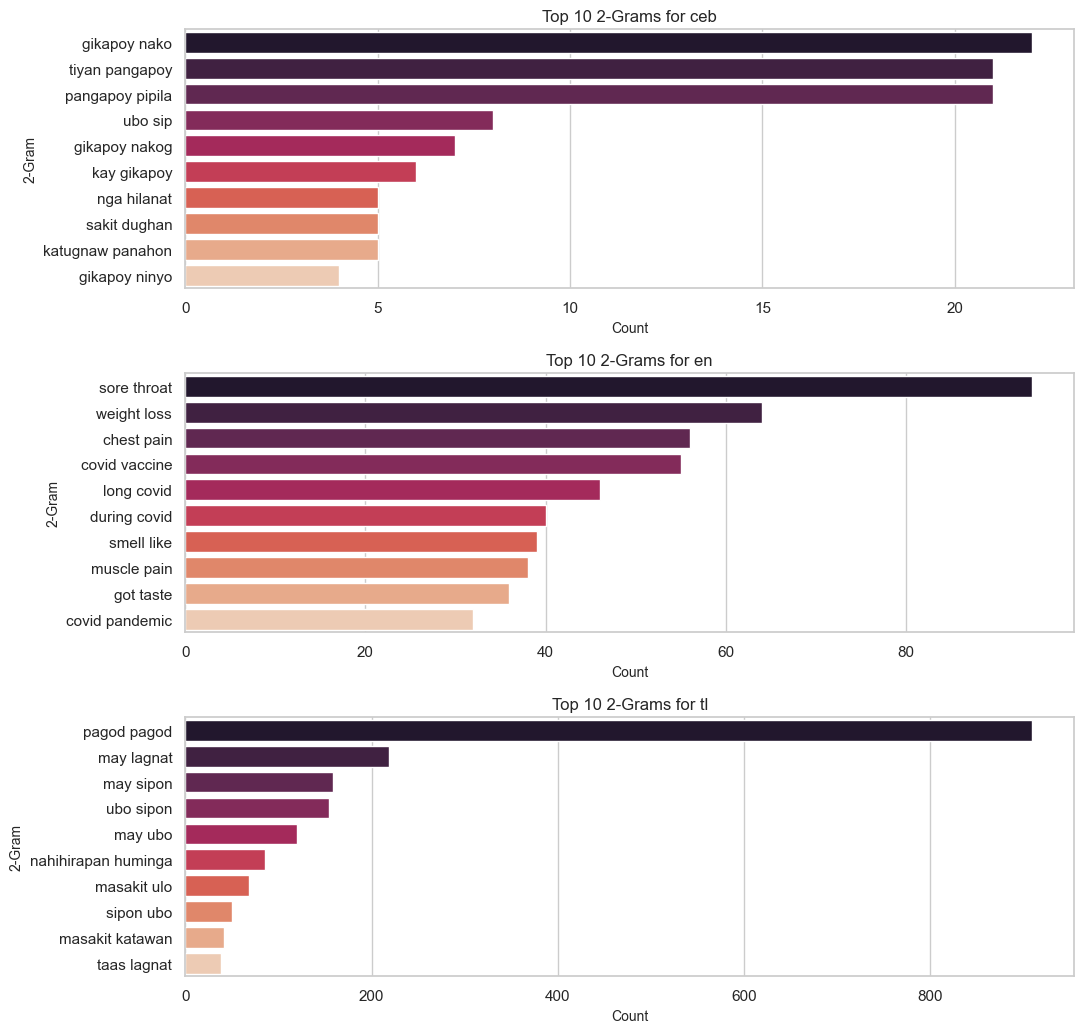

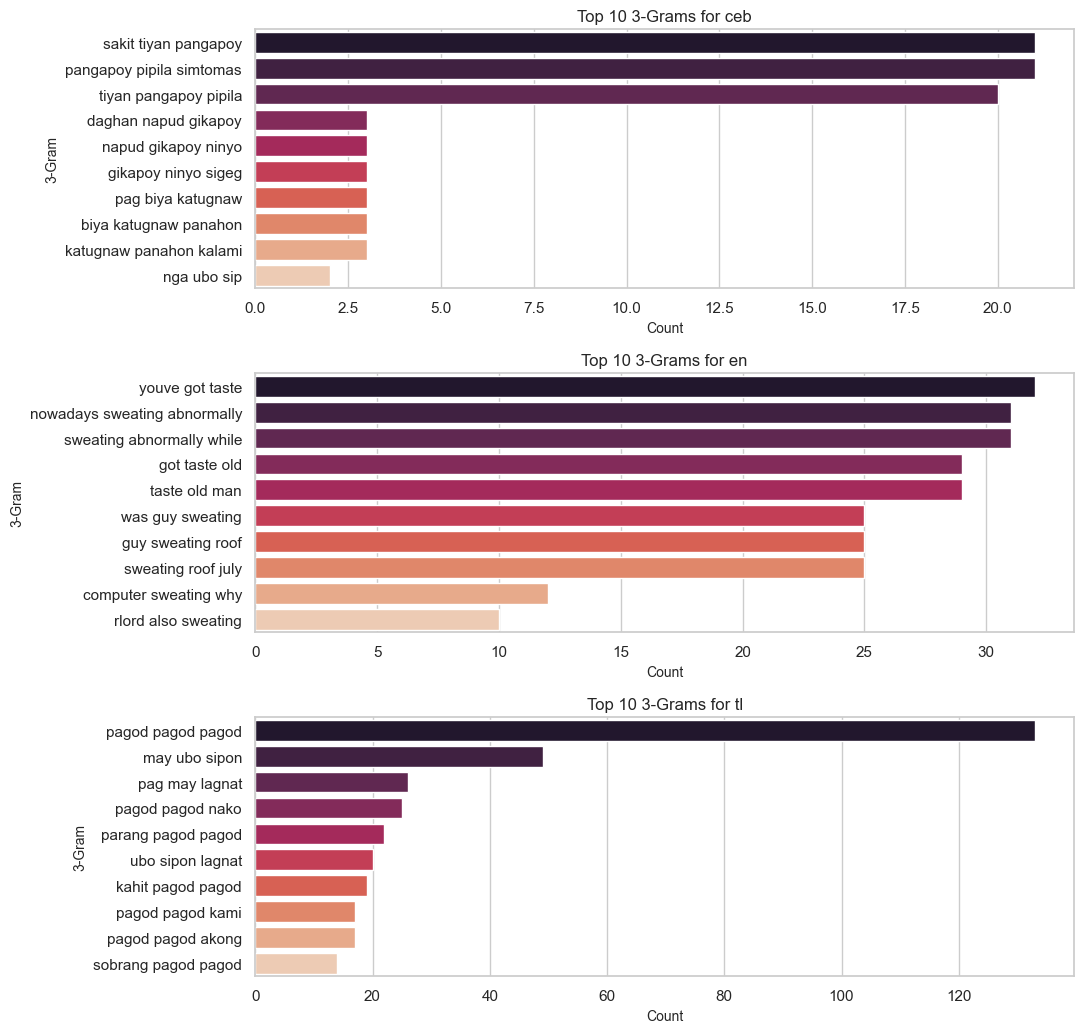

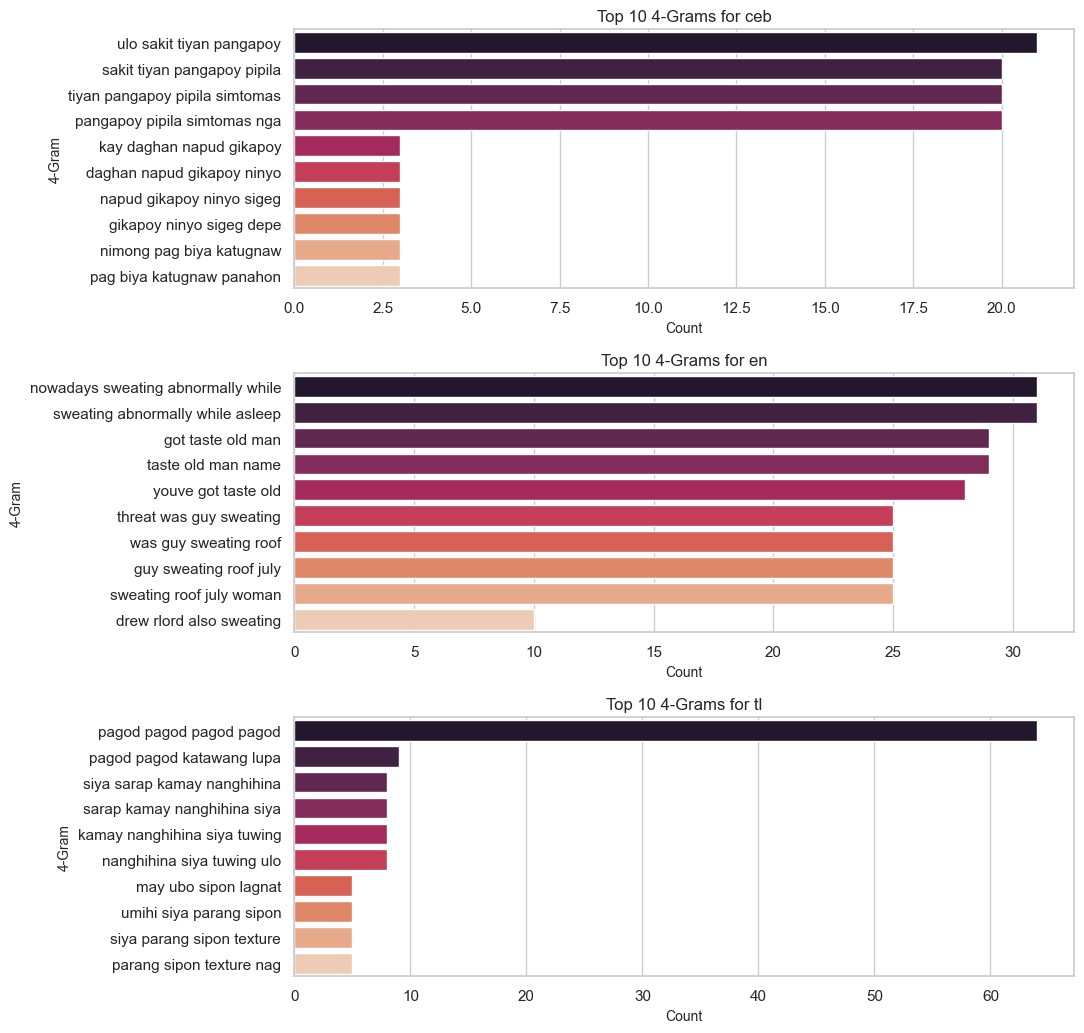

In [ ]:
if 'language' not in df.columns:
    print('No language column found.')
elif not analysis_text_col:
    print('No cleaned_text or text column found for n-gram analysis.')
else:
    language_ngram_summary_df, language_ngram_counts_df = build_language_ngram_counts(
        df,
        LANGUAGE_KEYWORD_FILES,
        text_col=analysis_text_col,
        ngram_sizes=(2, 3, 4),
        top_k=10,
    )

    display(language_ngram_summary_df)

    if language_ngram_counts_df.empty:
        print('No keyword-linked n-grams could be generated from the available text.')
    else:
        for ngram_size in [2, 3, 4]:
            ngram_table = (
                language_ngram_counts_df[language_ngram_counts_df['ngram_size'] == ngram_size]
                .groupby('language', group_keys=False)
                .head(10)
                .reset_index(drop=True)
            )
            if not ngram_table.empty:
                print(f'Top {ngram_size}-grams by language')
                display(ngram_table)

        plot_language_ngram_summary(language_ngram_counts_df, top_k=10)


### Interpreting the N-Gram Graphs

- **2-grams** are the broadest keyword-anchored phrase signal. They usually capture the nearest modifiers and companion terms attached to a curated symptom or disease keyword.
- **3-grams** are more precise. They often show short symptom descriptions or repeated contextual phrases built around the keyword mention itself.
- **4-grams** are the narrowest and most sensitive to repetition. Strong 4-gram bars can indicate repeated templates, copied captions, or highly specific descriptions surrounding the curated vocabulary.
- If one language shows very flat 3-gram or 4-gram counts, that usually means keyword mentions appear in more varied contexts rather than in a few repeated expressions.
- If one language shows very concentrated 4-grams, inspect the underlying posts because the pattern may come from duplicated or near-duplicated content rather than naturally recurring discussion.


## 7) Language-Split Keyword Counts

This section checks how often curated disease and symptom keywords appear within each supported language group. The counts are **post-level**, which means a keyword is counted once per post even if it appears multiple times in the same text. This makes the summary easier to interpret as prevalence rather than repetition volume.

How to read the outputs:
- The configured language table confirms which keyword files are mapped to each dataset language code.
- The language summary table shows overall coverage: total posts, posts with at least one keyword match, match rate, and how many distinct curated keywords were actually observed.
- The top-keywords table highlights the strongest signals per language and is useful for spotting which symptoms or disease terms dominate discussion.
- The source-language summary table breaks those same metrics out by website and language.
- The first bar chart compares the **share of posts with at least one curated keyword** across languages.
- The per-language bar charts show which exact keywords contribute most to those match rates.
- The website-level bar charts then repeat that view for each source, separated by language.


,language,keyword_file,keyword_file_exists
0,en,english_keywords.csv,True
1,tl,filipino_keywords.csv,True
2,ceb,cebuano_keywords.csv,True
3,ilo,ilocano_keywords.csv,True
4,hil,hiligaynon_keywords.csv,True


,language,total_posts,posts_with_keyword,match_rate_pct,distinct_keywords_hit,keyword_file,keyword_count_available
0,en,15853,2814,17.75,42,english_keywords.csv,64
1,tl,13659,3059,22.40,40,filipino_keywords.csv,72
2,ceb,821,188,22.90,15,cebuano_keywords.csv,99
3,ilo,24,0,0.00,0,ilocano_keywords.csv,42
4,hil,0,0,0.00,0,hiligaynon_keywords.csv,28


,source,language,total_posts,posts_with_keyword,match_rate_pct,distinct_keywords_hit
0,facebook,tl,63,62,98.41,16
1,facebook,en,9,0,0.00,0
2,reddit,en,11471,1211,10.56,35
3,reddit,tl,11115,1606,14.45,37
4,reddit,ceb,523,82,15.68,9
5,reddit,ilo,15,0,0.00,0
6,threads,en,2384,1200,50.34,39
7,threads,tl,1055,180,17.06,18
8,threads,ceb,201,59,29.35,10
9,threads,ilo,5,0,0.00,0


,language,keyword,matched_post_count,match_rate_pct
0,en,covid,662,4.18
1,en,taste,335,2.11
2,en,fever,246,1.55
3,en,smell,238,1.50
4,en,sweating,197,1.24
5,en,cough,171,1.08
6,en,headache,141,0.89
7,en,weakness,140,0.88
8,en,fatigue,118,0.74
9,en,diarrhea,117,0.74


,source,language,keyword,matched_post_count,match_rate_pct
0,reddit,en,covid,558,4.86
1,reddit,en,taste,146,1.27
2,reddit,en,smell,120,1.05
3,reddit,en,fever,118,1.03
4,reddit,en,cough,61,0.53
...,...,...,...,...,...
112,twitter,ceb,hilanat,22,31.43
113,twitter,ceb,maluya,10,14.29
114,twitter,ceb,sip-on,6,8.57
115,twitter,ceb,gikapoy,5,7.14


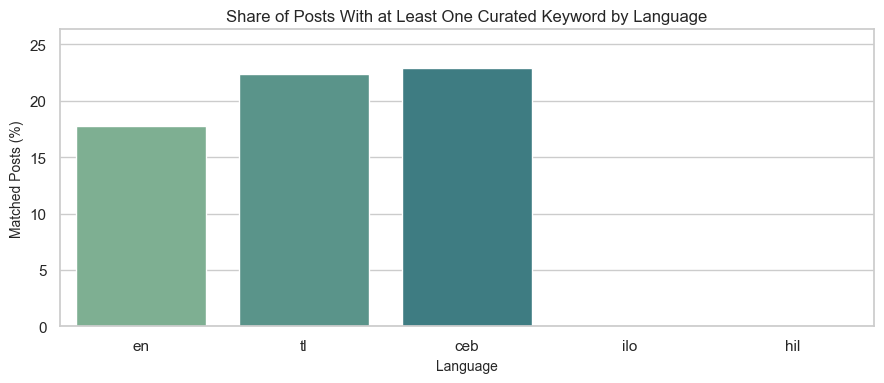

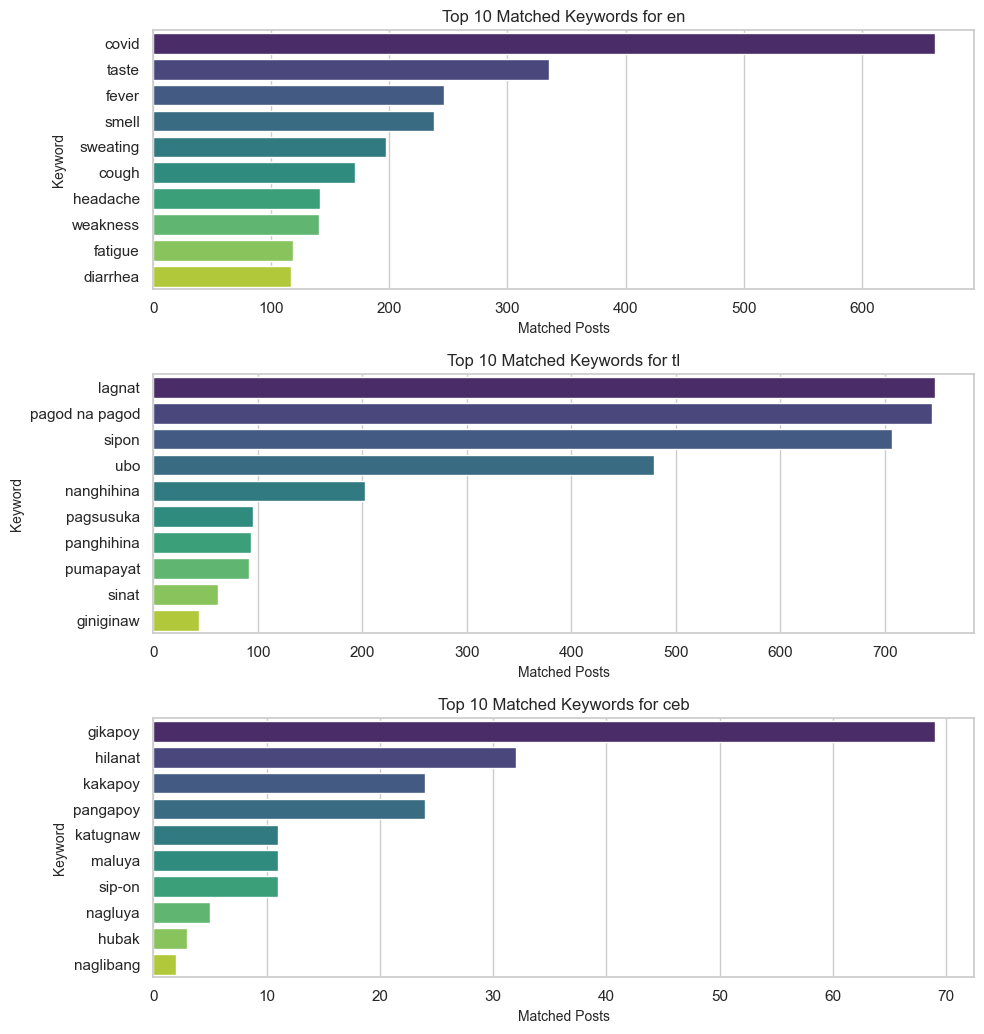

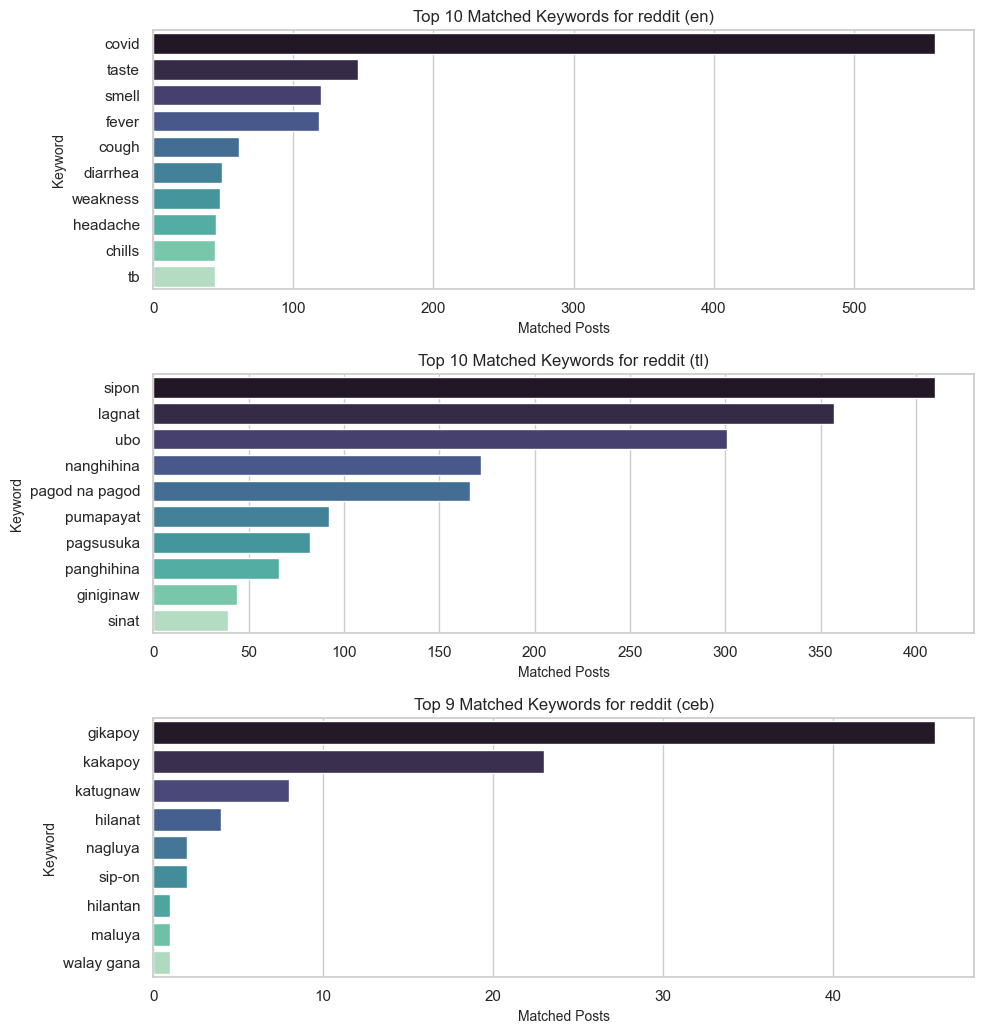

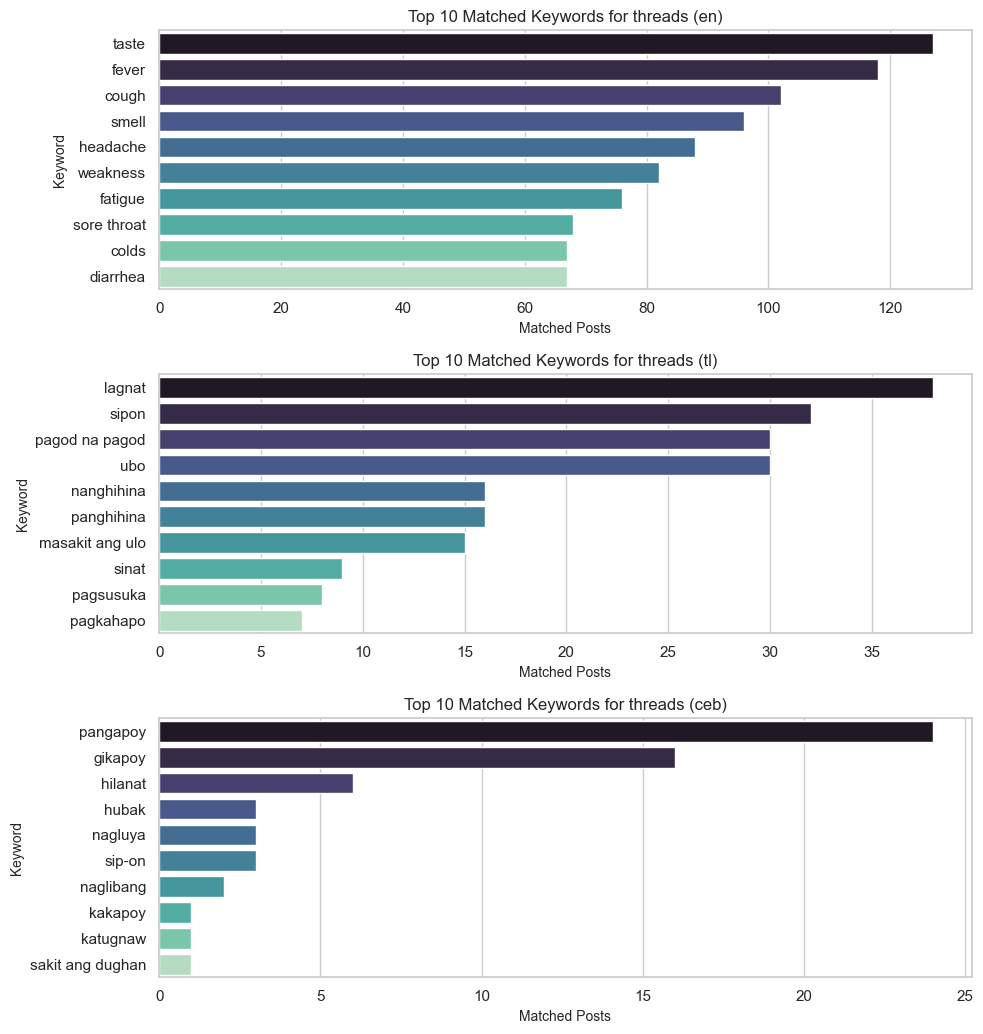

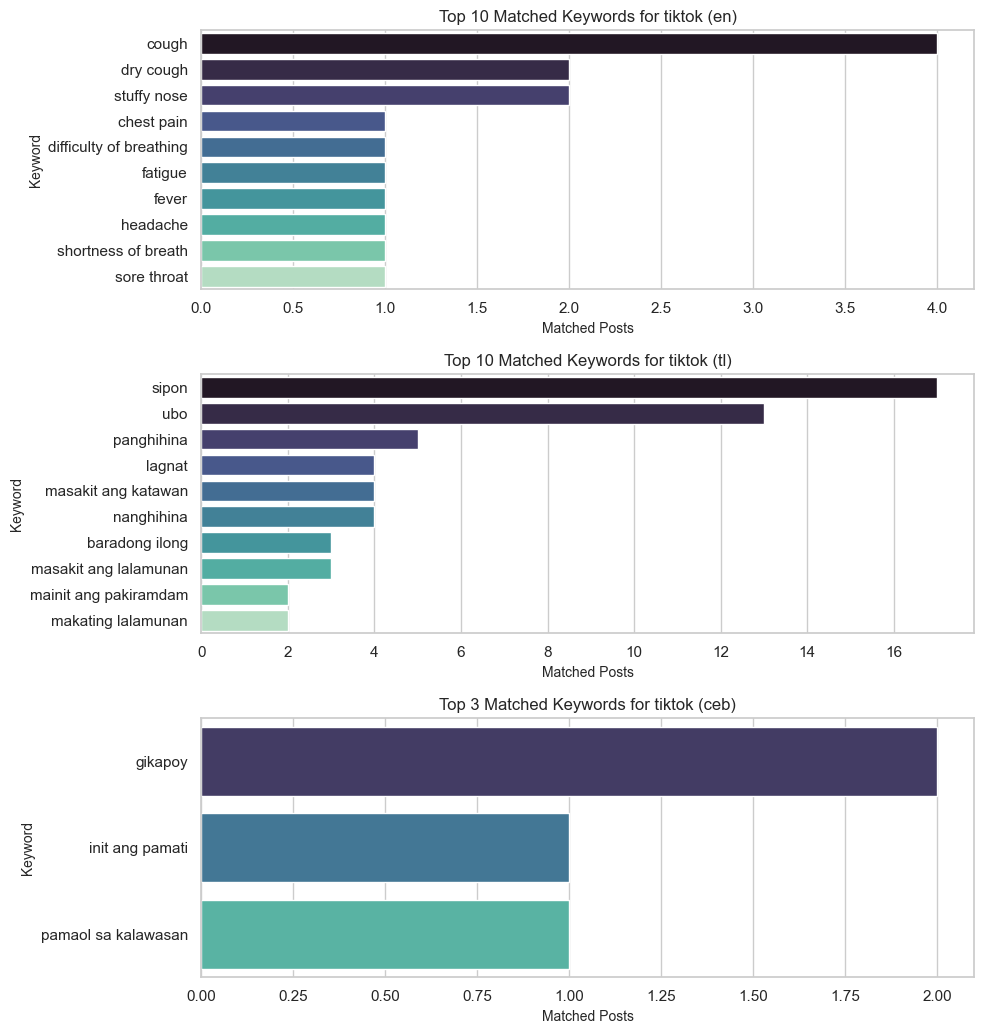

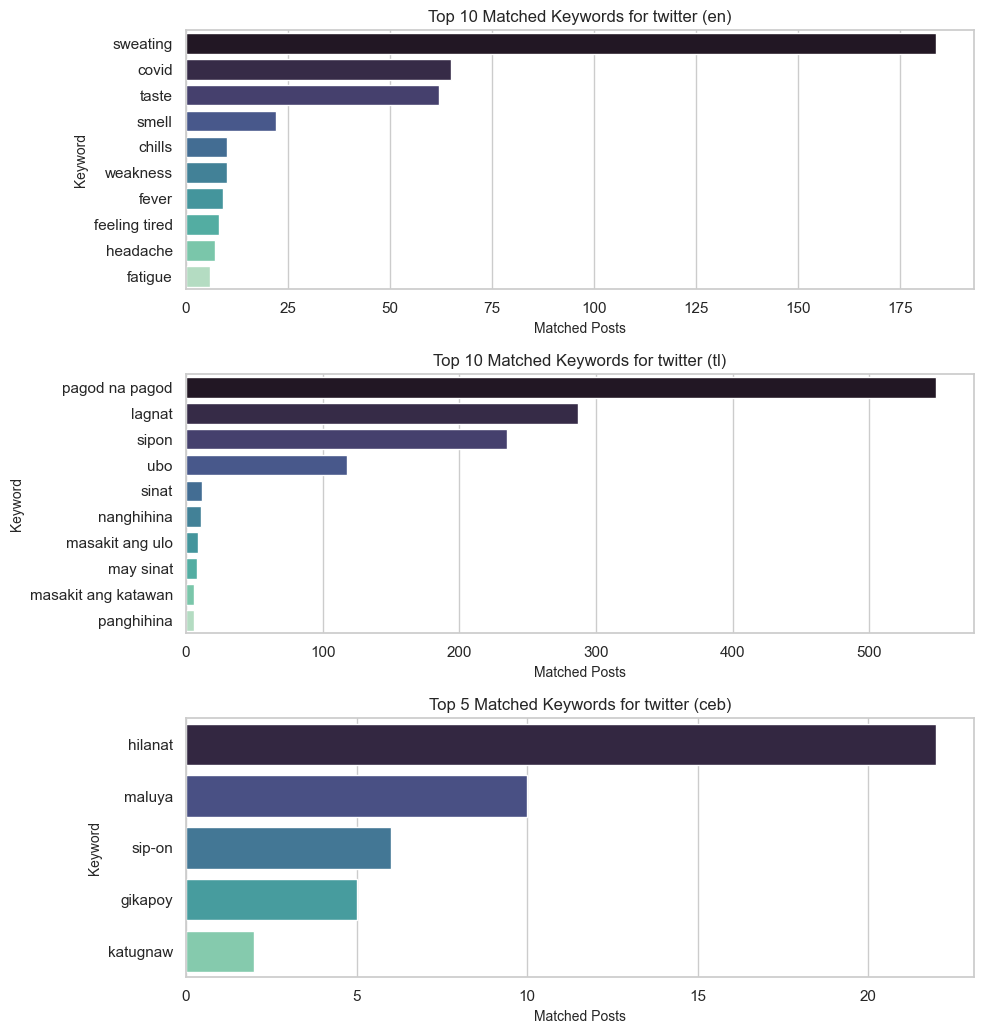

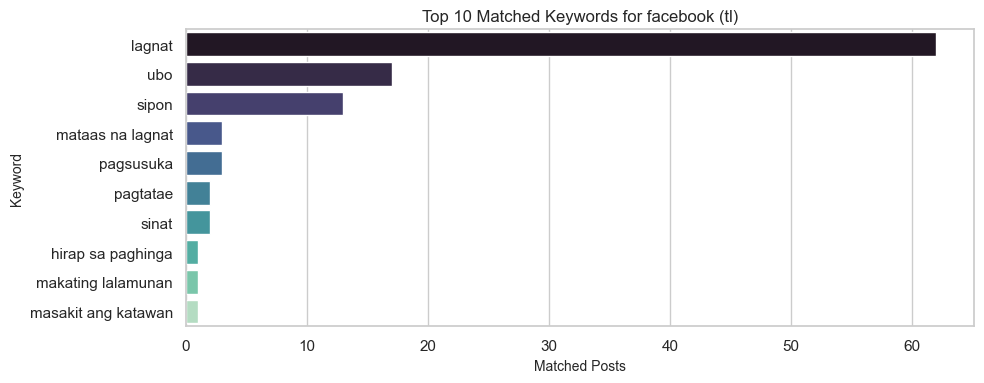

In [ ]:
if 'language' not in df.columns:
    print('No language column found.')
elif 'cleaned_text' not in df.columns and 'text' not in df.columns:
    print('No cleaned_text or text column found for keyword analysis.')
else:
    keyword_summary_df, language_keyword_counts_df, source_language_summary_df, source_language_keyword_counts_df = build_language_keyword_counts(
        df,
        LANGUAGE_KEYWORD_FILES,
        text_col='cleaned_text'
    )

    configured_languages = pd.DataFrame({
        'language': list(LANGUAGE_KEYWORD_FILES.keys()),
        'keyword_file': [path.name for path in LANGUAGE_KEYWORD_FILES.values()],
        'keyword_file_exists': [path.exists() for path in LANGUAGE_KEYWORD_FILES.values()]
    })
    display(configured_languages)

    display(keyword_summary_df)

    if not source_language_summary_df.empty:
        display(source_language_summary_df)

    top_language_keywords = (
        language_keyword_counts_df[language_keyword_counts_df['matched_post_count'] > 0]
        .groupby('language', group_keys=False)
        .head(10)
        .reset_index(drop=True)
    )

    if top_language_keywords.empty:
        print('No keyword matches found in the configured language groups.')
    else:
        display(top_language_keywords)

    top_source_language_keywords = (
        source_language_keyword_counts_df[source_language_keyword_counts_df['matched_post_count'] > 0]
        .groupby(['source', 'language'], group_keys=False)
        .head(10)
        .reset_index(drop=True)
    )

    if not top_source_language_keywords.empty:
        display(top_source_language_keywords)

    plot_language_keyword_summary(
        keyword_summary_df,
        language_keyword_counts_df,
        source_language_keyword_counts_df=source_language_keyword_counts_df,
        top_n=10,
    )



### Interpretation of the Keyword Graphs

Based on the current `merged_data.csv` snapshot, Filipino (`tl`) and Cebuano (`ceb`) have the highest keyword-match rates at about **22.4%** and **22.9%**, while English (`en`) is lower at **17.75%**. In absolute volume, however, English and Filipino still dominate the analysis because they have far more posts than the other language groups.

The match-rate chart should therefore be read together with the `total_posts` column. A high rate in Cebuano indicates concentrated keyword usage within a smaller sample, not necessarily a larger overall burden of symptom-related discussion than Filipino or English.

The top-keyword plots show different language-specific patterns:
- English is led by broad disease and symptom terms such as `covid`, `taste`, `fever`, `smell`, and `cough`.
- Filipino is driven by highly recognizable symptom words such as `lagnat`, `sipon`, `ubo`, and weakness or fatigue-related expressions like `pagod na pagod` and `nanghihina`.
- Cebuano has fewer total matches, but the strongest signals are still symptom-oriented, especially `gikapoy`, `hilanat`, and related weakness or cold-feeling terms.

Sparse-language results need extra caution. Ilocano currently has only **24** posts and no matched curated keywords, while Hiligaynon has no rows in this dataset snapshot. Those zero bars should be interpreted as limited coverage in the current sample, not evidence that relevant symptoms are absent in those languages.

One EDA caveat is that keyword matching captures literal mention, not context. Some posts may mention symptom words metaphorically or outside a true health context, so these charts are best used for signal discovery and keyword auditing rather than as direct epidemiological counts.


## 8) Engagement Metrics and Correlation


,count,mean,std,min,50%,75%,90%,95%,99%,max
view_count,1802.0,159377.55,1221997.70,0.0,5.0,672.75,90780.0,476490.0,3099000.00,28600000.0
like_count,26123.0,429.26,4046.09,0.0,4.0,22.00,120.0,407.9,7742.12,144679.0
share_count,2089.0,724.03,6532.39,0.0,0.0,8.00,231.0,1453.4,13272.00,184400.0
comment_count,985.0,193.51,1127.87,0.0,1.0,27.00,198.0,654.2,4688.12,26600.0
engagement_total,30357.0,9886.19,300670.21,0.0,3.0,20.00,137.0,599.4,45838.96,28610069.0


,non_null_pct,zero_pct,max_value
view_count,5.94,96.78,28600000.0
like_count,86.05,25.05,144679.0
share_count,6.88,97.32,184400.0
comment_count,3.24,98.16,26600.0


view_count                                 like_count         \
              count   median       mean         max      count median   
source                                                                  
facebook          0      NaN        NaN         NaN         72   97.0   
reddit            0      NaN        NaN         NaN      23124    5.0   
threads         825      0.0       0.00         0.0       1293    1.0   
tiktok          543  24600.0  528518.06  28600000.0          0    NaN   
twitter         434     19.0     490.88     43102.0       1634    0.0   

                            share_count                            \
             mean       max       count median     mean       max   
source                                                              
facebook  4024.26   79231.0           0    NaN      NaN       NaN   
reddit     450.43  144679.0           0    NaN      NaN       NaN   
threads    375.36   44854.0         467    0.0    73.51    3373.0   
tiktok        NaN       NaN         543   29.0  2716.60  184400.0   
twitter     13.93    8883.0        1079    0.0     2.84    1094.0   

         comment_count                         engagement_total           \
                 count median    mean      max            count   median   
source                                                                     
facebook             0    NaN     NaN      NaN               72     97.0   
reddit               0    NaN     NaN      NaN            23124      5.0   
threads              0    NaN     NaN      NaN             3645      0.0   
tiktok             543   20.0  350.77  26600.0              543  24745.0   
twitter            442    0.0    0.31     12.0             2973      0.0   

                                 
               mean         max  
source                           
facebook    4024.26     79231.0  
reddit       450.43    144679.0  
threads      142.57     46464.0  
tiktok    531585.43  28610069.0  
twitter       80.39     43904.0

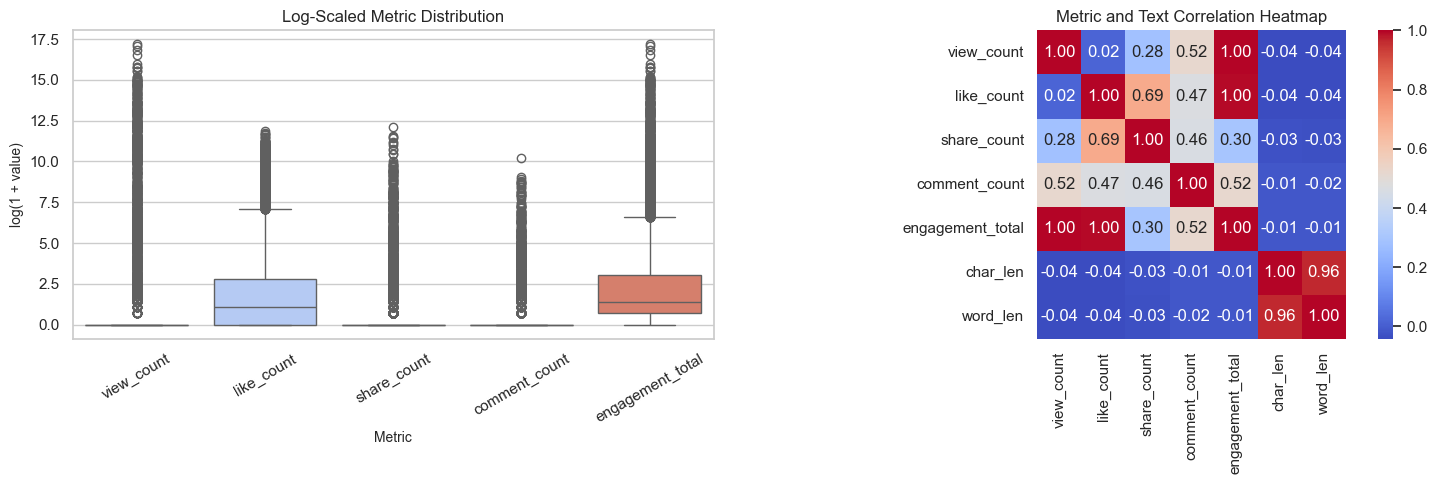

,source,language,analysis_date,engagement_total,view_count,like_count,share_count,comment_count,cleaned_text
30162,tiktok,en,2022-02-13 09:19:13+00:00,28610069.0,28600000.0,NaN,3608.0,6461.0,the good king and the beggar's spicy food
30163,tiktok,en,2022-03-11 10:25:52+00:00,26511023.0,26500000.0,NaN,2443.0,8580.0,spicy fire noodles spam mukbang eating sounds
30306,tiktok,en,2024-01-19 22:53:28+00:00,20126460.0,20100000.0,NaN,18800.0,7660.0,follow and learn about why you would have air ...
30335,tiktok,tl,2024-09-20 04:30:10+00:00,15402870.0,15400000.0,NaN,2344.0,526.0,"madaling pagkapagod, panghihina o bawas na gan..."
30201,tiktok,en,2022-08-10 13:22:46+00:00,8818618.0,8800000.0,NaN,14100.0,4518.0,heres my version of beer by itchyworms tara shat
30070,tiktok,tl,2024-11-21 00:30:00+00:00,7195132.0,7100000.0,NaN,92900.0,2232.0,hindi raw dapat binabalewala ang pagkakaroon n...
29951,tiktok,en,2024-07-28 22:09:17+00:00,7009063.0,7000000.0,NaN,6402.0,2661.0,sipping on pepsi
30217,tiktok,en,2025-10-24 18:50:20+00:00,6613504.0,6600000.0,NaN,12000.0,1504.0,hirschsprung disease (3d animation)
30104,tiktok,en,2026-01-14 09:58:37+00:00,5709775.0,5600000.0,NaN,106300.0,3475.0,"may ubo, sipon, masakit lalamunan? panuorin mo to"
30132,tiktok,tl,2023-08-21 08:03:55+00:00,5503895.0,5500000.0,NaN,2969.0,926.0,namanhid ang left arm ko at nanginig ako kagab...


In [ ]:
if not metric_cols:
    print('No engagement metric columns found.')
else:
    metric_summary = df[metric_cols + ['engagement_total']].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).transpose().round(2)
    display(metric_summary)

    metric_health = pd.DataFrame({
        'non_null_pct': (df[metric_cols].notna().mean() * 100).round(2),
        'zero_pct': ((df[metric_cols].fillna(0) == 0).mean() * 100).round(2),
        'max_value': df[metric_cols].max()
    })
    display(metric_health)

    if 'source' in df.columns:
        metric_by_source = df.groupby('source')[metric_cols + ['engagement_total']].agg(['count', 'median', 'mean', 'max']).round(2)
        display(metric_by_source)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    log_metric_df = np.log1p(df[metric_cols + ['engagement_total']].fillna(0))
    sns.boxplot(data=log_metric_df.melt(var_name='metric', value_name='log_value'), x='metric', y='log_value', ax=axes[0], palette='coolwarm')
    axes[0].set_title('Log-Scaled Metric Distribution')
    axes[0].set_xlabel('Metric')
    axes[0].set_ylabel('log(1 + value)')
    axes[0].tick_params(axis='x', rotation=30)

    corr_cols = metric_cols + [col for col in ['engagement_total', 'char_len', 'word_len'] if col in df.columns]
    corr = df[corr_cols].corr(numeric_only=True)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, ax=axes[1])
    axes[1].set_title('Metric and Text Correlation Heatmap')

    plt.tight_layout()
    plt.show()

    top_post_cols = [col for col in ['source', 'language', 'analysis_date', 'engagement_total'] + metric_cols + ['cleaned_text'] if col in df.columns]
    display(df.nlargest(10, 'engagement_total')[top_post_cols])


## 9) Representative Records and Outliers


In [ ]:
example_cols = [col for col in ['source', 'language', 'analysis_date', 'external_post_id', 'word_len', 'char_len', 'engagement_total', 'cleaned_text'] if col in df.columns]

if 'word_len' in df.columns:
    print('Longest posts by word count')
    display(df.nlargest(10, 'word_len')[example_cols])

    print('Shortest non-empty posts')
    shortest_non_empty = df[df['word_len'] > 0].nsmallest(10, 'word_len')
    display(shortest_non_empty[example_cols])

if 'engagement_total' in df.columns:
    print('Highest-engagement posts')
    display(df.nlargest(10, 'engagement_total')[example_cols])

if 'is_empty_text' in df.columns and df['is_empty_text'].any():
    print('Rows with empty cleaned text')
    display(df[df['is_empty_text']][example_cols].head(10))


Longest posts by word count


,source,language,analysis_date,external_post_id,word_len,char_len,engagement_total,cleaned_text
27143,reddit,en,2026-02-21 03:17:09+00:00,1ra4nds,7980,37683,2.0,anatomy of karen read's abusive behavior towar...
7928,reddit,tl,2025-05-31 01:28:31+00:00,1kza64o,7121,38985,0.0,"2years of courting, and i've been betrayed by ..."
7919,reddit,tl,2025-05-30 10:33:49+00:00,1kyt8m3,7062,38684,12.0,"2 years of courting, at mayayari lang ito dahi..."
27126,reddit,en,2026-03-06 21:04:54+00:00,1rmdgaw,6959,35620,50.0,the cafae: of lovers and warriors 27/28 [first...
7922,reddit,tl,2025-05-01 19:50:56+00:00,1kc6shu,6932,37983,8.0,2yrs of courting tapos nag cheat sya saakin! i...
14700,reddit,en,2026-05-14 17:35:03+00:00,1tct389,6874,37134,3.0,clouds the morning when god decided to talk to...
15171,reddit,en,2026-02-16 08:01:30+00:00,1r5u9mi,6838,35353,1.0,poems about my life poem 1:soundproof heart.3/...
27131,reddit,en,2026-02-27 21:38:03+00:00,1rg6wzo,6831,34498,48.0,the cafae: of lovers and warriors 26/28 [first...
14642,reddit,en,2026-05-14 22:37:43+00:00,1td0571,6826,37162,3.0,"sarah *i'm feeling a bit nostalgic today, so i..."
29374,reddit,en,2025-09-08 12:07:39+00:00,1nbdxmv,6739,32232,3.0,"1,182 words of blakwada kriyul / blackwater sw..."


Shortest non-empty posts


,source,language,analysis_date,external_post_id,word_len,char_len,engagement_total,cleaned_text
24,twitter,en,2025-11-20 21:55:34+00:00,1991626497883595208,1,10,0.0,libertango
210,twitter,en,2025-09-21 15:19:25+00:00,1969783533959794765,1,3,0.0,ubo
333,twitter,ceb,2025-06-21 23:39:47+00:00,1936569767999287594,1,5,0.0,sakit
615,twitter,en,2026-02-18 09:52:54+00:00,2024059540317360462,1,18,0.0,panghihina....yang
1796,twitter,en,2026-03-05 02:18:26+00:00,2029380987738583083,1,5,0.0,ules.
1800,twitter,en,2026-03-08 02:07:02+00:00,2030465284528595232,1,4,0.0,ules
1822,twitter,en,2026-04-06 07:07:16+00:00,2041050086960939509,1,6,3.0,yayyyy
1826,twitter,en,2026-04-03 20:25:35+00:00,2040163826482507829,1,5,10.0,fairs
1937,twitter,en,2026-03-09 04:28:21+00:00,2030863233511276881,1,8,0.0,yup!!!!!
1945,twitter,en,2026-03-15 21:38:12+00:00,2033296731631226932,1,7,0.0,#.ules.


Highest-engagement posts


,source,language,analysis_date,external_post_id,word_len,char_len,engagement_total,cleaned_text
30162,tiktok,en,2022-02-13 09:19:13+00:00,7064121484805000450,8,41,28610069.0,the good king and the beggar's spicy food
30163,tiktok,en,2022-03-11 10:25:52+00:00,7073786874313084162,7,45,26511023.0,spicy fire noodles spam mukbang eating sounds
30306,tiktok,en,2024-01-19 22:53:28+00:00,7325946246575721771,14,70,20126460.0,follow and learn about why you would have air ...
30335,tiktok,tl,2024-09-20 04:30:10+00:00,7416577900322786568,19,122,15402870.0,"madaling pagkapagod, panghihina o bawas na gan..."
30201,tiktok,en,2022-08-10 13:22:46+00:00,7130237398994242842,9,48,8818618.0,heres my version of beer by itchyworms tara shat
30070,tiktok,tl,2024-11-21 00:30:00+00:00,7439434405711531280,32,180,7195132.0,hindi raw dapat binabalewala ang pagkakaroon n...
29951,tiktok,en,2024-07-28 22:09:17+00:00,7396812208950316320,3,16,7009063.0,sipping on pepsi
30217,tiktok,en,2025-10-24 18:50:20+00:00,7564862549208861975,4,35,6613504.0,hirschsprung disease (3d animation)
30104,tiktok,en,2026-01-14 09:58:37+00:00,7595154476135107841,8,49,5709775.0,"may ubo, sipon, masakit lalamunan? panuorin mo to"
30132,tiktok,tl,2023-08-21 08:03:55+00:00,7269683250547805446,23,116,5503895.0,namanhid ang left arm ko at nanginig ako kagab...


Rows with empty cleaned text


,source,language,analysis_date,external_post_id,word_len,char_len,engagement_total,cleaned_text
93,twitter,en,2025-10-21 20:28:05+00:00,1980732845242085651,0,0,0.0,
216,twitter,en,2025-11-20 05:55:48+00:00,1991384963309269005,0,0,0.0,
294,twitter,en,2025-04-22 23:51:57+00:00,1914829559826145584,0,0,0.0,
1780,twitter,en,2026-02-12 15:28:10+00:00,2021969585029906909,0,0,0.0,
1787,twitter,en,2026-03-22 17:26:55+00:00,2035770209189994611,0,0,0.0,
1788,twitter,en,2026-03-27 09:34:23+00:00,2037463231288246302,0,0,0.0,
1794,twitter,en,2026-03-09 16:55:09+00:00,2031051173302550774,0,0,0.0,
1867,twitter,en,2026-03-17 04:16:50+00:00,2033759439854178340,0,0,0.0,
1868,twitter,en,2026-03-07 16:05:20+00:00,2030313862185009497,0,0,6.0,
1871,twitter,en,2026-03-07 17:44:35+00:00,2030338836191154616,0,0,0.0,


## 10) Quick Findings Template

Use this section after running the notebook to capture the highest-signal findings:
- Which 2-grams, 3-grams, and 4-grams dominate within each supported language.
- Which curated keywords appear most often within each supported language.
- Which platforms dominate volume and which are sparsest.
- Whether language coverage matches expectations for the collected sources.
- Which fields are weakest by source and need preprocessing fixes.
- Whether there are duplicate ids, duplicate texts, or suspiciously short/empty posts.
- Which dates, weekdays, and hours are overrepresented.
- How text length differs by platform.
- Whether engagement metrics are usable enough for downstream modeling or ranking.
- Which outlier posts should be manually reviewed before training.
